# Online Shoppers Purchasing Intention — predicting a purchase

**Task:** binary classification — predict whether a website visitor will complete a purchase (`Revenue`) based on their behavior on the site (pages viewed, time spent, traffic type, etc.).

**Dataset:** [Online Shoppers Purchasing Intention Dataset (UCI)](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset), 12,330 sessions, 17 features + target variable `Revenue` (bool).

**Why this dataset:**
- Real tabular data with a mix of numerical and categorical features
- A clear class imbalance (~85% / 15%) — lets us test hypotheses about accuracy vs F1
- Enough data for an honest train/test split and cross-validation

The dataset consists of 10 numerical and 8 categorical attributes.
The 'Revenue' attribute can be used as the class label.

"Administrative", "Administrative Duration", "Informational", "Informational Duration", "Product Related" and "Product Related Duration" represent the number of different types of pages visited by the visitor in that session and total time spent in each of these page categories. The values of these features are derived from the URL information of the pages visited by the user and updated in real time when a user takes an action, e.g. moving from one page to another. The "Bounce Rate", "Exit Rate" and "Page Value" features represent the metrics measured by "Google Analytics" for each page in the e-commerce site. The value of "Bounce Rate" feature for a web page refers to the percentage of visitors who enter the site from that page and then leave ("bounce") without triggering any other requests to the analytics server during that session. The value of "Exit Rate" feature for a specific web page is calculated as for all pageviews to the page, the percentage that were the last in the session. The "Page Value" feature represents the average value for a web page that a user visited before completing an e-commerce transaction. The "Special Day" feature indicates the closeness of the site visiting time to a specific special day (e.g. Mother’s Day, Valentine's Day) in which the sessions are more likely to be finalized with transaction. The value of this attribute is determined by considering the dynamics of e-commerce such as the duration between the order date and delivery date. For example, for Valentina’s day, this value takes a nonzero value between February 2 and February 12, zero before and after this date unless it is close to another special day, and its maximum value of 1 on February 8. The dataset also includes operating system, browser, region, traffic type, visitor type as returning or new visitor, a Boolean value indicating whether the date of the visit is weekend, and month of the year.

## Hypotheses

1. **Random Forest will beat logistic regression on ROC-AUC**, because the relationship between the features and a purchase might turn out to be nonlinear
2. **An unrestricted decision tree depth will lead to overfitting**, i.e. train F1 macro will keep rising while test F1 macro drops, compared to a depth-limited tree.
3. **`PageValues` will turn out to be the most important feature** by random forest feature importance, since it's a direct measure of a page's value for conversion.
4. **Dropping one of two strongly correlated features won't meaningfully hurt** logistic regression's AUC
5. **Ridge regularization (L2) will beat unregularized logistic regression on test AUC**, thanks to handling multicollinearity between features.
6. **F1 macro will be noticeably lower than accuracy** because of the class imbalance (~85%/15%).
7. **Selecting the top 10 features with SelectKBest won't meaningfully hurt quality** compared to the full feature set after one-hot encoding, since some features are probably not very informative.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              roc_auc_score, ConfusionMatrixDisplay)

## 1. Loading the data

In [2]:
df = pd.read_csv('online_shoppers_intention.csv')
print(df.shape)
df.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 2. EDA

### 2.1 General info and missing values

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

There are no missing values in the data.

### 2.2 Distribution of the target variable (class imbalance)

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64


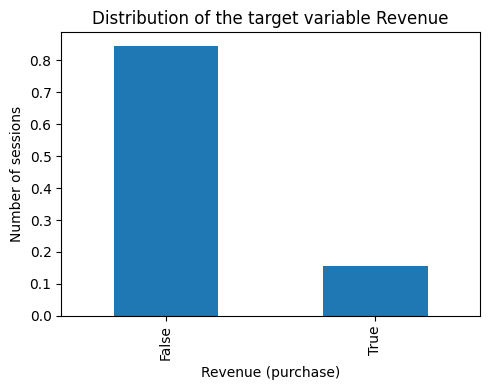

In [4]:
target_counts = df['Revenue'].value_counts(normalize=True)
print(target_counts)

fig, ax = plt.subplots(figsize=(5,4))
target_counts.plot(kind='bar', ax=ax)
ax.set_title('Distribution of the target variable Revenue')
ax.set_xlabel('Revenue (purchase)')
ax.set_ylabel('Number of sessions')
plt.tight_layout()
plt.show()

The `True` class (purchase made) makes up only ~15.5% of the sample — a clear imbalance. This directly affects hypothesis #6 (accuracy vs F1 macro).

### 2.3 Distributions of numerical features

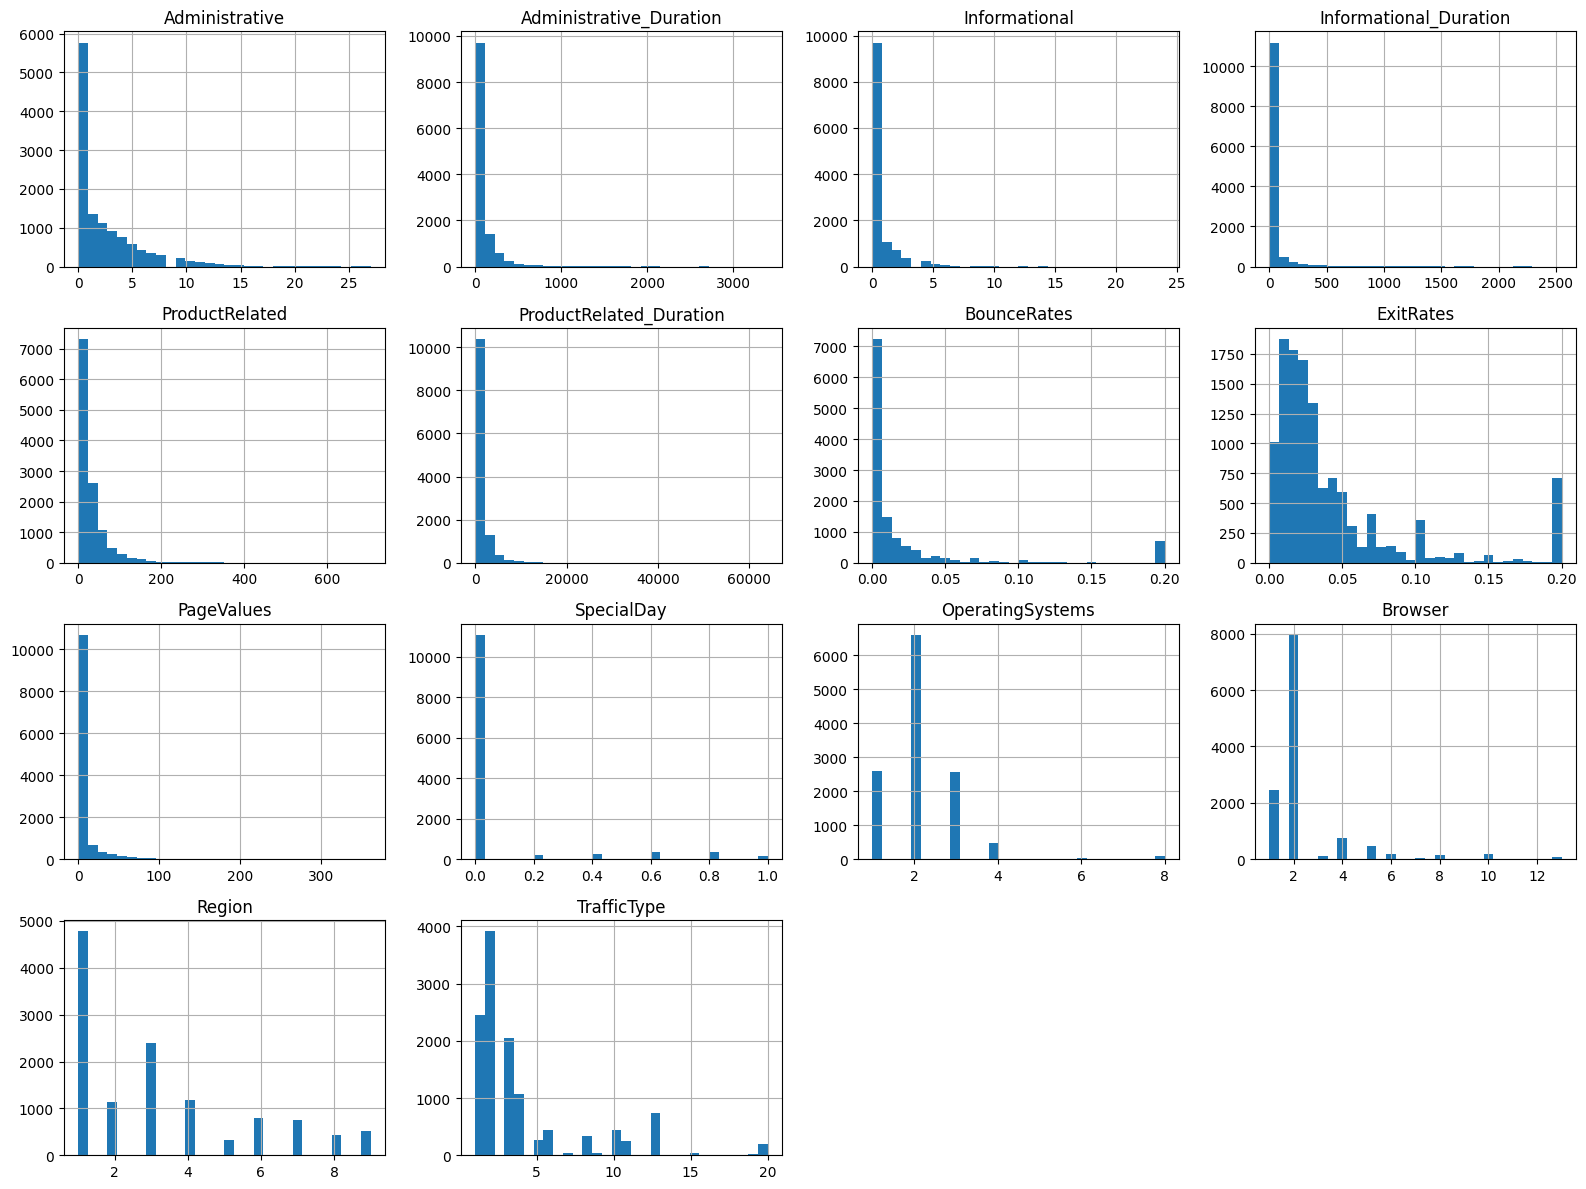

In [5]:
num_cols = df.select_dtypes(include='number').columns.tolist()
df[num_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

Most numerical features (Administrative_Duration, ProductRelated, BounceRates, ExitRates, PageValues) are heavily right-skewed — lots of sessions with zero or low activity, and a long tail of active users.

### 2.4 Correlations between numerical features

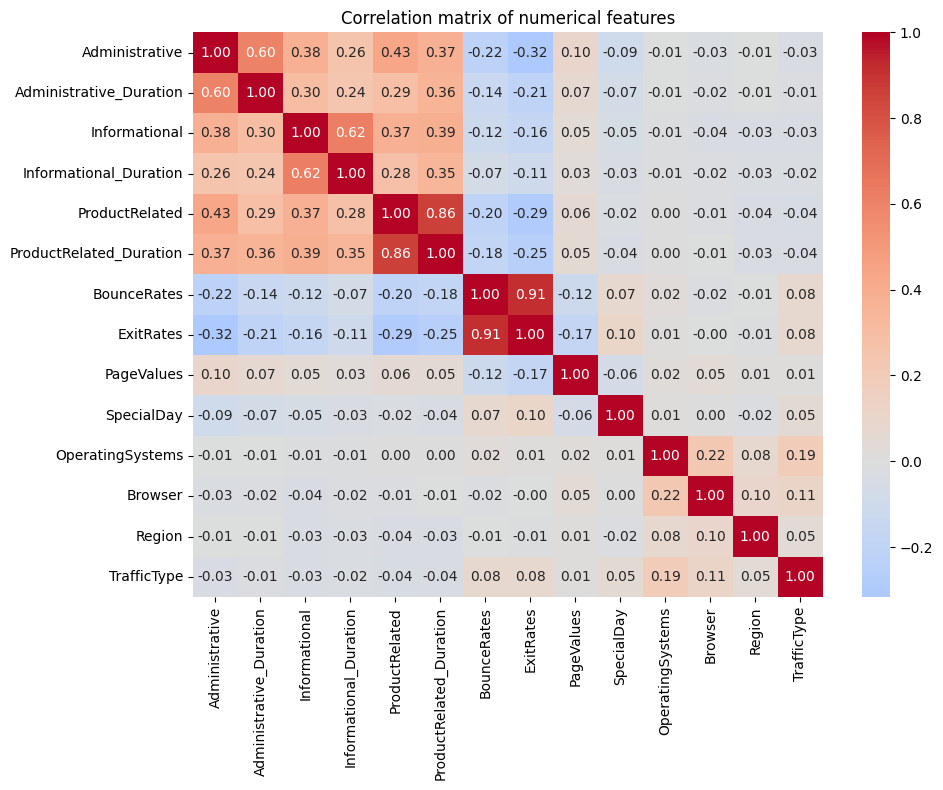

In [6]:
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation matrix of numerical features')
plt.tight_layout()
plt.show()

`BounceRates` and `ExitRates` correlate at **0.91**, which could indirectly support hypotheses #4 and #5.

### 2.5 Categorical features

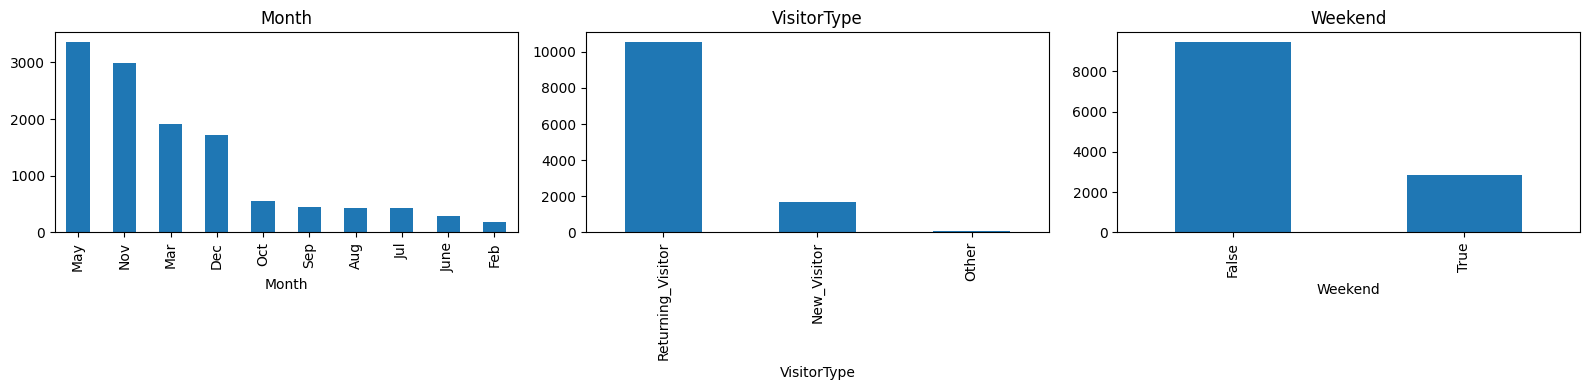

In [7]:
cat_cols = ['Month', 'VisitorType', 'Weekend']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

`Month` — most sessions fall in May, November, March and December. Possibly related to holidays somehow. There's no data for January and April, worth checking — might be a data export issue. `VisitorType` is heavily skewed toward Returning_Visitor. Worth keeping in mind when interpreting the importance of these features.

### 2.6 Looking for nonlinearity

Plain correlation (section 2.4) only shows a linear relationship. To see how nonlinear a feature's relationship with a purchase actually is, let's split each numerical feature into 10 bins (by quantile) and compute the purchase rate (Revenue=True) within each bin. If the relationship were linear, the points would fall roughly on a straight line.

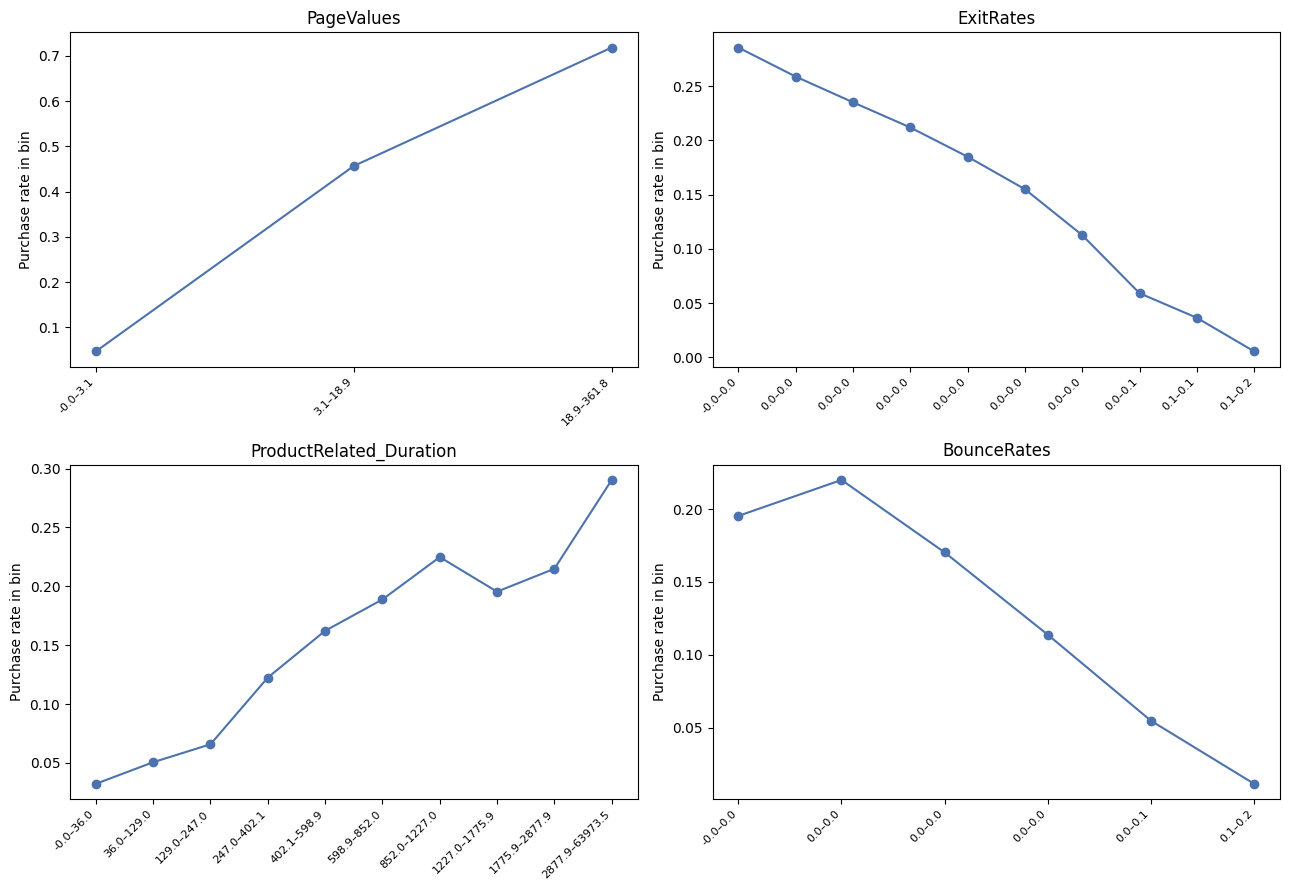

In [8]:
features_to_check = ['PageValues', 'ExitRates', 'ProductRelated_Duration', 'BounceRates']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for ax, col in zip(axes, features_to_check):
    bins = pd.qcut(df[col], q=10, duplicates='drop')
    conv_rate = df['Revenue'].astype(int).groupby(bins, observed=True).mean()
    # bin edges for the X axis
    x_labels = [f'{b.left:.1f}–{b.right:.1f}' for b in conv_rate.index]

    ax.plot(range(len(conv_rate)), conv_rate.values, marker='o', color='#4C72B0')
    ax.set_xticks(range(len(conv_rate)))
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Purchase rate in bin')
    ax.set_title(col)

plt.tight_layout()
plt.show()

The nonlinearity is clearly visible:

- **`PageValues`** — a sharp jump in purchase rate: from ~5% in the lower bins to ~72% in the top one. Nowhere near a straight line — a linear model approximates this kind of "jump" poorly, while a decision tree can just place a split threshold at the right spot.
- **`ExitRates`** and **`BounceRates`** — the purchase rate decreases, but not linearly — more like a decaying curve (fast drop at the start, nearly flat tail at the end) — closer to exponential decay than a straight line.
- **`ProductRelated_Duration`** — the relationship isn't even monotonic: the purchase rate rises, but dips in the middle of the range (~1200–1800 seconds) before rising again. A linear model fundamentally can't capture a non-monotonic relationship — a tree/forest can.

This is empirical support for hypothesis 1 (Random Forest will beat LogReg on AUC): the data itself shows nonlinear and non-monotonic relationships between the target and the features, even before we've trained a single model.

## 3. Preparing the data

- No missing values — no imputation needed.
- Numerical features → `StandardScaler` (important for logistic regression and its regularization).
- Categorical (`Month`, `VisitorType`, `Weekend`) → `OneHotEncoder`.
- Train/test split — 80/20, stratified by `Revenue` (because of the class imbalance).

In [9]:
X = df.drop(columns='Revenue')
y = df['Revenue']

cat_cols = ['Month', 'VisitorType', 'Weekend']
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Purchase rate in train:', y_train.mean().round(4), ' in test:', y_test.mean().round(4))

Train: (9864, 17)  Test: (2466, 17)
Purchase rate in train: 0.1547  in test: 0.1549


## 4. Models: LogReg, Decision Tree, Random Forest

We train three models through a single `Pipeline` (preprocessing + classifier), and compare them by accuracy, and especially by F1 macro and ROC-AUC, since we have class imbalance. No GridSearch hyperparameter tuning yet.

In [10]:
models = {
    'LogReg (weak regularization, C=1e6)': LogisticRegression(C=1e6, max_iter=2000),
    'LogReg L2 (Ridge-like, C=1.0)': LogisticRegression(C=1.0, max_iter=2000),
    'LogReg L1 (Lasso-like, C=1.0)': LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000),
    'Decision Tree (unrestricted)': DecisionTreeClassifier(random_state=42),
    'Random Forest (200 trees)': RandomForestClassifier(random_state=42, n_estimators=200),
}

rows = []
fitted_pipes = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('clf', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'f1_macro': f1_score(y_test, pred, average='macro'),
        'roc_auc': roc_auc_score(y_test, proba)
    })
    fitted_pipes[name] = pipe

results_df = pd.DataFrame(rows).set_index('model').round(4)
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,accuracy,f1_macro,roc_auc
model,,,
"LogReg (weak regularization, C=1e6)",0.8812,0.7072,0.8872
"LogReg L2 (Ridge-like, C=1.0)",0.8812,0.7072,0.8876
"LogReg L1 (Lasso-like, C=1.0)",0.8816,0.7086,0.8877
Decision Tree (unrestricted),0.8564,0.7264,0.7269
Random Forest (200 trees),0.9023,0.7895,0.9212


**Hypothesis 1 (RF > LogReg on AUC):** Random Forest does indeed give a higher ROC-AUC than every variant of logistic regression — the model captures nonlinear relationships better.

**Hypothesis 6 (F1 macro noticeably lower than accuracy):** for every model, F1 macro is noticeably lower than accuracy, which is expected given the class imbalance.

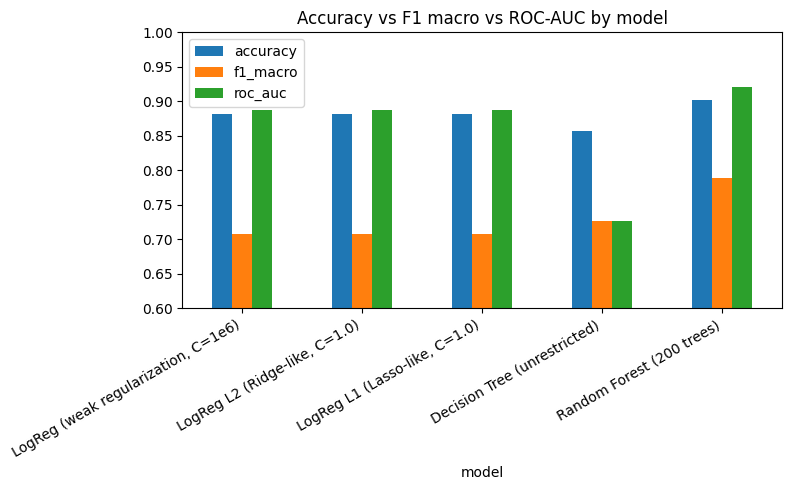

In [11]:
fig, ax = plt.subplots(figsize=(8,5))
results_df[['accuracy', 'f1_macro', 'roc_auc']].plot(kind='bar', ax=ax)
ax.set_title('Accuracy vs F1 macro vs ROC-AUC by model')
ax.set_ylim(0.6, 1.0)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Classification report for the best model (Random Forest)

              precision    recall  f1-score   support

 No purchase       0.92      0.97      0.94      2084
    Purchase       0.75      0.55      0.64       382

    accuracy                           0.90      2466
   macro avg       0.84      0.76      0.79      2466
weighted avg       0.90      0.90      0.90      2466



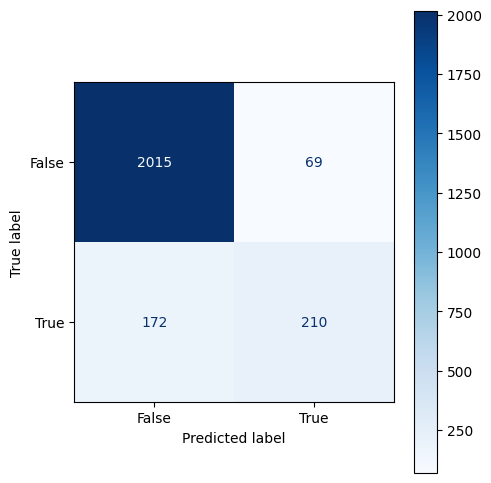

In [12]:
best_pipe = fitted_pipes['Random Forest (200 trees)']
pred = best_pipe.predict(X_test)
print(classification_report(y_test, pred, target_names=['No purchase', 'Purchase']))

fig, ax = plt.subplots(figsize=(5,5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax, cmap='Blues')
plt.tight_layout()
plt.show()

## 5. Checking decision tree overfitting (hypothesis 2)

We train trees with different `max_depth` and compare **F1 macro** on train and test. We also compute accuracy, for comparison.

In [13]:
depths = [2, 4, 6, 8, 10, 15, 20, None]
depth_rows = []
for depth in depths:
    pipe = Pipeline([('prep', preprocess), ('clf', DecisionTreeClassifier(max_depth=depth, random_state=42))])
    pipe.fit(X_train, y_train)
    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)
    depth_rows.append({
        'max_depth': str(depth),
        'train_f1_macro': f1_score(y_train, train_pred, average='macro'),
        'test_f1_macro': f1_score(y_test, test_pred, average='macro'),
        'train_acc': accuracy_score(y_train, train_pred),
        'test_acc': accuracy_score(y_test, test_pred),
    })

depth_df = pd.DataFrame(depth_rows)
depth_df

,max_depth,train_f1_macro,test_f1_macro,train_acc,test_acc
0,2,0.757790,0.732246,0.892234,0.886050
1,4,0.785297,0.761220,0.904603,0.896188
2,6,0.829767,0.778185,0.917072,0.893755
3,8,0.858467,0.771412,0.931671,0.890511
4,10,0.897823,0.758017,0.949412,0.882401
5,15,0.978034,0.735248,0.988646,0.863747
6,20,0.998058,0.737323,0.998986,0.864964
7,None,1.000000,0.726443,1.000000,0.856448


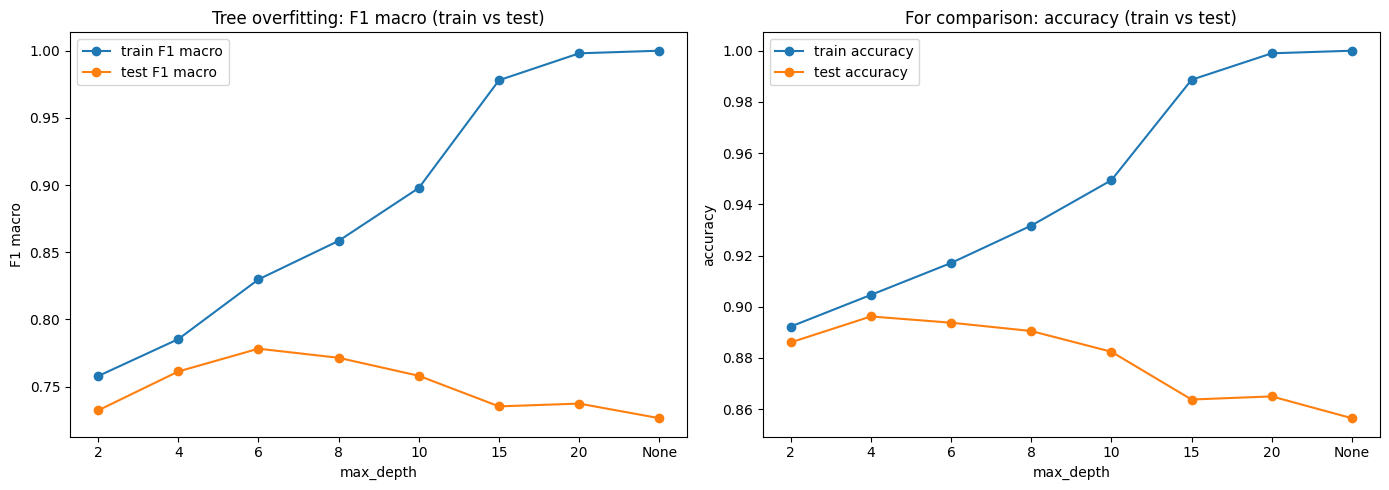

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(depth_df['max_depth'], depth_df['train_f1_macro'], marker='o', label='train F1 macro')
axes[0].plot(depth_df['max_depth'], depth_df['test_f1_macro'], marker='o', label='test F1 macro')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('F1 macro')
axes[0].set_title('Tree overfitting: F1 macro (train vs test)')
axes[0].legend()

axes[1].plot(depth_df['max_depth'], depth_df['train_acc'], marker='o', label='train accuracy')
axes[1].plot(depth_df['max_depth'], depth_df['test_acc'], marker='o', label='test accuracy')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('accuracy')
axes[1].set_title('For comparison: accuracy (train vs test)')
axes[1].legend()

plt.tight_layout()
plt.show()

**Hypothesis 2:** confirmed on F1 macro. At `max_depth=None`, train F1 macro reaches **1.0** (the tree memorizes the train set entirely), while test F1 macro is noticeably **lower** than for a tree with an optimal depth (6: test F1 macro ≈ 0.78 vs ≈ 0.73 with no depth limit).

## 6. Multicollinearity: dropping `BounceRates` (hypothesis 4)

`BounceRates` and `ExitRates` correlate at 0.91 (see EDA). Let's check whether logistic regression's AUC changes if we drop `BounceRates`.

In [15]:
num_reduced = [c for c in num_cols if c != 'BounceRates']
preprocess_reduced = ColumnTransformer([
    ('num', StandardScaler(), num_reduced),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

pipe_full = Pipeline([('prep', preprocess), ('clf', LogisticRegression(max_iter=2000))]).fit(X_train, y_train)
pipe_reduced = Pipeline([('prep', preprocess_reduced), ('clf', LogisticRegression(max_iter=2000))]).fit(X_train, y_train)

auc_full = roc_auc_score(y_test, pipe_full.predict_proba(X_test)[:, 1])
auc_reduced = roc_auc_score(y_test, pipe_reduced.predict_proba(X_test)[:, 1])

print('AUC with all features:', round(auc_full, 4))
print('AUC without BounceRates:', round(auc_reduced, 4))
print('difference:', round(auc_full - auc_reduced, 4))

AUC with all features: 0.8876
AUC without BounceRates: 0.8873
difference: 0.0003


**Hypothesis 4:** confirmed. The AUC difference from dropping `BounceRates` is a few thousandths — essentially statistically insignificant. `ExitRates` really does carry almost the same information, and removing the redundant feature doesn't hurt model quality (and makes the model easier to interpret, with less risk of unstable coefficients).

## 7. Ridge (L2) vs unregularized logistic regression (hypothesis 5)

In [16]:
auc_no_reg = roc_auc_score(y_test, fitted_pipes['LogReg (weak regularization, C=1e6)'].predict_proba(X_test)[:, 1])
auc_ridge = roc_auc_score(y_test, fitted_pipes['LogReg L2 (Ridge-like, C=1.0)'].predict_proba(X_test)[:, 1])
print('AUC without regularization (C=1e6):', round(auc_no_reg, 4))
print('AUC Ridge (C=1.0):', round(auc_ridge, 4))

AUC without regularization (C=1e6): 0.8872
AUC Ridge (C=1.0): 0.8876


**Hypothesis 5:** more likely not confirmed. Ridge does slightly outperform the unregularized model on test AUC, but again the difference is minimal. The multicollinearity in the data isn't strong enough (dropping/keeping `BounceRates`/`ExitRates` barely changes the numbers) for regularization to produce a meaningful quality gain, though it may still help with coefficient stability.

## 8. Feature importance (hypothesis 3)

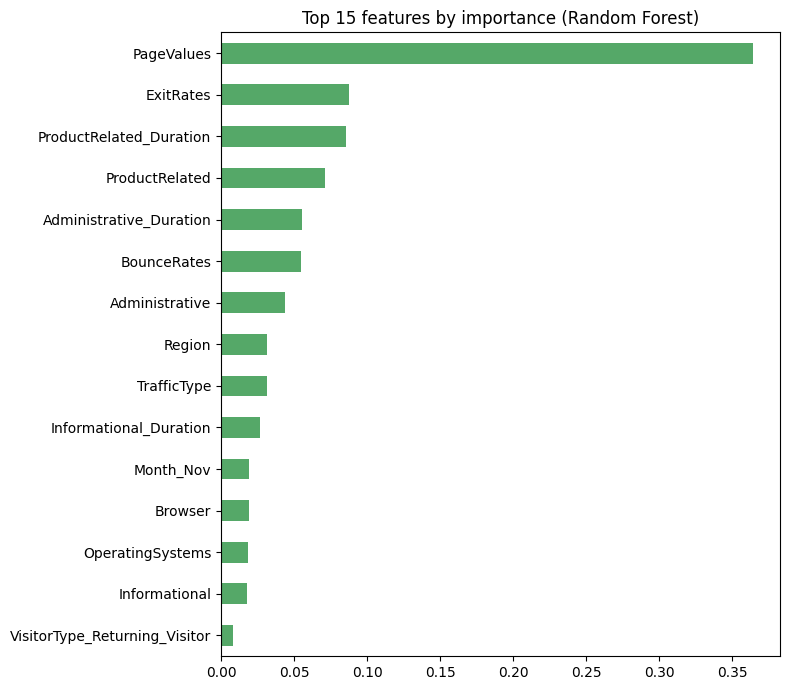

PageValues                 0.364365
ExitRates                  0.087725
ProductRelated_Duration    0.085442
ProductRelated             0.071389
Administrative_Duration    0.055389
BounceRates                0.054962
Administrative             0.043629
Region                     0.031321
TrafficType                0.031282
Informational_Duration     0.026819
dtype: float64

In [17]:
rf_pipe = fitted_pipes['Random Forest (200 trees)']
feat_names = num_cols + list(rf_pipe.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(cat_cols))
importances = rf_pipe.named_steps['clf'].feature_importances_
imp_series = pd.Series(importances, index=feat_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,7))
imp_series.head(15).sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Top 15 features by importance (Random Forest)')
plt.tight_layout()
plt.show()

imp_series.head(10)

**Hypothesis 3:** confirmed. `PageValues` is unambiguously the most important feature (importance ~0.36, several times higher than the next one, `ExitRates`). Makes sense: `PageValues` directly reflects how valuable the viewed pages are from a conversion standpoint.

`Month` and `VisitorType`, which looked unevenly distributed in the EDA, turned out to be among the least important — behavioral metrics matter far more to the model than "who" and "when" showed up.

## 9. Feature selection: SelectKBest (hypothesis 7)

In [18]:
prep_fitted = preprocess.fit(X_train)
X_train_t = prep_fitted.transform(X_train)
X_test_t = prep_fitted.transform(X_test)

skb = SelectKBest(f_classif, k=10)
X_train_skb = skb.fit_transform(X_train_t, y_train)
X_test_skb = skb.transform(X_test_t)

all_feat_names = num_cols + list(prep_fitted.named_transformers_['cat'].get_feature_names_out(cat_cols))
selected = np.array(all_feat_names)[skb.get_support()]
print('Selected top-10 features:', list(selected))

lr_full = LogisticRegression(max_iter=2000).fit(X_train_t, y_train)
lr_skb = LogisticRegression(max_iter=2000).fit(X_train_skb, y_train)

auc_full_feats = roc_auc_score(y_test, lr_full.predict_proba(X_test_t)[:, 1])
auc_skb_feats = roc_auc_score(y_test, lr_skb.predict_proba(X_test_skb)[:, 1])

print('AUC with all features (~30 after OHE):', round(auc_full_feats, 4))
print('AUC with top-10 features (SelectKBest):', round(auc_skb_feats, 4))

Selected top-10 features: [np.str_('Administrative'), np.str_('Administrative_Duration'), np.str_('ProductRelated'), np.str_('ProductRelated_Duration'), np.str_('BounceRates'), np.str_('ExitRates'), np.str_('PageValues'), np.str_('Month_Nov'), np.str_('VisitorType_New_Visitor'), np.str_('VisitorType_Returning_Visitor')]
AUC with all features (~30 after OHE): 0.8876
AUC with top-10 features (SelectKBest): 0.8853


**Hypothesis 7:** confirmed. Keeping just 10 of ~30 features (after one-hot encoding) lowers AUC only slightly (~0.002-0.003). This means most of the predictive information is carried by a small core of features, and the rest add little value — you can build a simpler, faster model with almost no loss in quality.

## 10. Hyperparameter tuning (GridSearchCV) and cross-validation

Section 4 compared models with manually chosen hyperparameters (needed for a clean comparison in hypotheses 1, 5, 6). Here we tune hyperparameters properly, with `GridSearchCV` and 5-fold cross-validation, optimizing F1 macro — for all three models: Decision Tree, LogReg, and Random Forest.

### 10.1 Decision Tree

In [19]:
pipe_gs = Pipeline([('prep', preprocess), ('clf', DecisionTreeClassifier(random_state=42))])
param_grid = {
    'clf__max_depth': [3, 5, 7, 10, 15],
    'clf__min_samples_leaf': [1, 5, 10, 20]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs_tree = GridSearchCV(pipe_gs, param_grid, scoring='f1_macro', cv=cv, n_jobs=-1)
gs_tree.fit(X_train, y_train)

print('Best params:', gs_tree.best_params_)
print('Best CV f1_macro:', round(gs_tree.best_score_, 4))

tree_pred = gs_tree.predict(X_test)
print('Test accuracy:', round(accuracy_score(y_test, tree_pred), 4))
print('Test f1_macro:', round(f1_score(y_test, tree_pred, average='macro'), 4))

Best params: {'clf__max_depth': 5, 'clf__min_samples_leaf': 20}
Best CV f1_macro: 0.7937
Test accuracy: 0.8994
Test f1_macro: 0.7936


The tuned tree (`max_depth=5, min_samples_leaf=20`), with a much shallower depth, beats the unrestricted tree from section 4 on F1 macro — one more confirmation of hypothesis 2 about unrestricted trees overfitting.

### 10.2 Logistic regression — tuning the regularization strength C

In [20]:
pipe_lr = Pipeline([('prep', preprocess), ('clf', LogisticRegression(max_iter=2000))])
param_grid_lr = {'clf__C': [0.001, 0.01, 0.1, 1, 10, 100]}

gs_lr = GridSearchCV(pipe_lr, param_grid_lr, scoring='f1_macro', cv=cv, n_jobs=-1)
gs_lr.fit(X_train, y_train)

print('Best params:', gs_lr.best_params_)
print('Best CV f1_macro:', round(gs_lr.best_score_, 4))

lr_pred = gs_lr.predict(X_test)
print('Test accuracy:', round(accuracy_score(y_test, lr_pred), 4))
print('Test f1_macro:', round(f1_score(y_test, lr_pred, average='macro'), 4))

Best params: {'clf__C': 100}
Best CV f1_macro: 0.7215
Test accuracy: 0.8812
Test f1_macro: 0.7072


The best value is `C=100`, i.e. almost no regularization (a large C means a weak penalty). Quality is essentially unchanged from the models in section 4 (`C=1.0` and `C=1e6`) — logistic regression on this data is insensitive to regularization strength, which lines up with the conclusion for hypothesis 5: the multicollinearity here isn't strong enough for regularization to give a noticeable boost.

### 10.3 Random Forest — tuning the number of trees and depth

In [21]:
pipe_rf = Pipeline([('prep', preprocess), ('clf', RandomForestClassifier(random_state=42))])
param_grid_rf = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_leaf': [1, 5]
}

gs_rf = GridSearchCV(pipe_rf, param_grid_rf, scoring='f1_macro', cv=cv, n_jobs=-1)
gs_rf.fit(X_train, y_train)

print('Best params:', gs_rf.best_params_)
print('Best CV f1_macro:', round(gs_rf.best_score_, 4))

rf_pred = gs_rf.predict(X_test)
print('Test accuracy:', round(accuracy_score(y_test, rf_pred), 4))
print('Test f1_macro:', round(f1_score(y_test, rf_pred, average='macro'), 4))

Best params: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}
Best CV f1_macro: 0.7992
Test accuracy: 0.9023
Test f1_macro: 0.7895


The best configuration (`n_estimators=200, max_depth=None, min_samples_leaf=1`) matches what was already used “by default” in section 4 — grid search confirmed that the baseline choice of parameters for Random Forest was already good; there isn't much room left to improve without a wider grid or other hyperparameters (`max_features`, `max_samples`).

### 10.4 Final comparison of the tuned models via cross-validation

In [22]:
# Cross-validation to compare the stability of the best version of each model (not just a single point estimate on one train/test split)
cv_results = {}
for name, model in {
    'LogReg (C=100, best from GridSearch)': LogisticRegression(C=100, max_iter=2000),
    'Decision Tree (max_depth=5, min_samples_leaf=20)': DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42),
    'Random Forest (n_estimators=200)': RandomForestClassifier(random_state=42, n_estimators=200)
}.items():
    pipe = Pipeline([('prep', preprocess), ('clf', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro')
    cv_results[name] = scores
    print(f'{name}: f1_macro CV = {scores.mean():.4f} ± {scores.std():.4f}')

LogReg (C=100, best from GridSearch): f1_macro CV = 0.7215 ± 0.0134


Decision Tree (max_depth=5, min_samples_leaf=20): f1_macro CV = 0.7937 ± 0.0191


Random Forest (n_estimators=200): f1_macro CV = 0.7992 ± 0.0106


## 11. Choosing a classification threshold for a business goal

If the goal is a marketing campaign where it matters more **not to miss a buyer** (high recall for class 1), let's try to pick a threshold by looking at how precision, recall and F1 change together with the threshold.

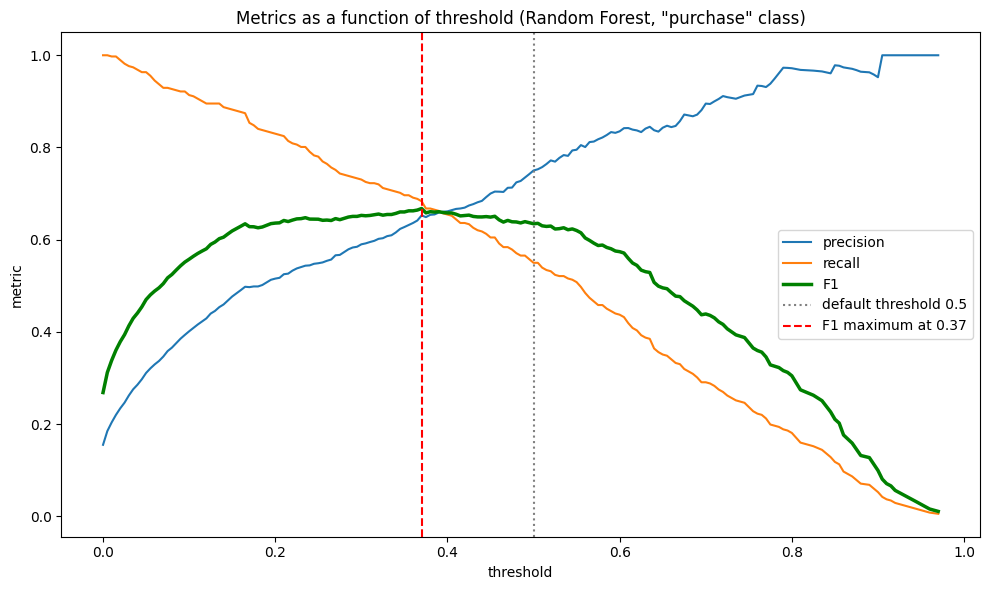

In [23]:
from sklearn.metrics import precision_recall_curve

best_rf = gs_rf.best_estimator_
proba = best_rf.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, proba)
f1_curve = 2 * precision * recall / (precision + recall + 1e-12)

best_idx = f1_curve[:-1].argmax()
best_threshold = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, precision[:-1], label='precision')
ax.plot(thresholds, recall[:-1], label='recall')
ax.plot(thresholds, f1_curve[:-1], label='F1', linewidth=2.5, color='green')
ax.axvline(0.5, color='grey', linestyle=':', label='default threshold 0.5')
ax.axvline(best_threshold, color='red', linestyle='--', label=f'F1 maximum at {best_threshold:.2f}')
ax.set_xlabel('threshold')
ax.set_ylabel('metric')
ax.set_title('Metrics as a function of threshold (Random Forest, "purchase" class)')
ax.legend()
plt.tight_layout()
plt.show()

If, from a business standpoint, we can sacrifice precision to maximize recall, we could pick a threshold around 0.1 — recall would then be about 0.9, meaning we'd catch roughly 90% of visitors who are genuinely ready to buy, out of the whole stream of site visitors. But precision would then be around 0.4, meaning 6 out of 10 flagged visitors would be a false alarm. If that trade-off is acceptable from the business side and in terms of how site visitors react to it, then this is a great threshold.

## 12. Conclusions per hypothesis

| # | Hypothesis | Result | Why |
|---|----------|-----------|--------|
| 1 | Random Forest beats LogReg on ROC-AUC | ✅ Confirmed | RF gives a noticeably higher AUC — the model captures nonlinear relationships a linear model can't |
| 2 | An unrestricted tree overfits (train F1 macro↑, test F1 macro↓) | ✅ Confirmed | At max_depth=None, train F1 macro = 1.0, test F1 macro (≈0.73) is lower than for a moderate-depth (6-8) tree (≈0.78) |
| 3 | PageValues is the most important feature | ✅ Confirmed | PageValues importance (~0.36) is several times higher than any other feature |
| 4 | Dropping BounceRates (corr>0.9 with ExitRates) won't hurt AUC | ✅ Confirmed | AUC difference is a few thousandths — the feature is redundant |
| 5 | Ridge beats unregularized LogReg on AUC | ⚠️ More likely not confirmed | Ridge is slightly better, but the difference is within noise — multicollinearity in the data isn't critical enough |
| 6 | F1 macro is noticeably lower than accuracy due to imbalance | ✅ Confirmed | A 10-18 point gap between accuracy and F1 macro across all models |
| 7 | Top-10 features (SelectKBest) won't hurt quality | ✅ Confirmed | AUC drops by only ~0.002-0.003 when the feature set is cut to a third |

**Overall conclusion:** for this task, nonlinear models (Random Forest) clearly outperform linear ones, the key feature is `PageValues`, and targeted refinements (regularization, the full feature set) give minimal gains compared to the basic choice of model and metric. Because of the class imbalance, it's important to always look at F1 macro / ROC-AUC, not just accuracy.